# 08 - Level 1b: PV Household Classification & Segmented Forecasting

Reads `data/processed/panel_train.parquet` / `panel_test.parquet` and
`model_table_schema.json`, the same stage-3 artefacts consumed by
`07_level0_baseline.ipynb`.

**Scope:** two independent questions on top of the Level 0 pooled Random Forest.

- **Part 1** - can a PV household be identified from consumption behaviour alone,
  without the `Installation_HasPVSystem` metadata flag?
- **Part 2** - does splitting the pooled model into a PV-only and a non-PV-only
  Random Forest beat the single pooled model from Level 0, evaluated on the
  same rows with the same metrics?

**Rebuilt against the current panel.** This notebook replaces an earlier version
that had drifted out of sync with the panel in two ways: it filtered
`Installation_HasPVSystem` with a string comparison (`== "True"`) against what is
now a genuine boolean column, which silently produced an empty PV segment rather
than an error; and it referenced `kWh_spike_flag`, a column present upstream but
dropped from the panel under `panel_slim`. Both are fixed here, and the feature
set for the segmented models is now aligned to the frozen Level 0 feature list
rather than an ad-hoc subset, so the comparison in Part 2 is apples-to-apples
with `level0_baseline_report.md`.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error,
)
from scipy.stats import norm

_here = Path.cwd()
REPO_ROOT = next((p for p in [_here, *_here.parents] if (p / "data" / "processed").is_dir()), _here)
PROCESSED = REPO_ROOT / "data" / "processed"
REPORTS_DIR = REPO_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.figsize": (13, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("tab10")
print(f"REPO_ROOT : {REPO_ROOT}")


REPO_ROOT : /home/claude/work


## STEP 0 - Load the panel, apply the same contract gate as Level 0

Same fail-loud checks as `07_level0_baseline.ipynb`: the schema is the contract,
so nothing here is retyped from a hardcoded column list.


In [2]:
train = pd.read_parquet(PROCESSED / "panel_train.parquet")
test = pd.read_parquet(PROCESSED / "panel_test.parquet")
SCHEMA = json.loads((PROCESSED / "model_table_schema.json").read_text())

TARGET = SCHEMA["target"]
SPLIT_CUTOFF = pd.Timestamp(SCHEMA["split_cutoff"])
WEATHER_SHIFT = SCHEMA["weather_shift_days"]
GROUPS = SCHEMA["feature_groups"]
SCHEMA_FEATURES = [c for g in GROUPS.values() for c in g]

missing = [c for c in SCHEMA_FEATURES + [TARGET, "Household_ID", "date"] if c not in train.columns]
assert not missing, f"columns promised by the schema but absent from the panel: {missing}"
assert set(train.columns) == set(test.columns), "train/test column-set drift"
assert train[TARGET].notna().all() and test[TARGET].notna().all(), "target must be present on every row"
assert train["date"].max() <= test["date"].min(), "train/test temporal order violated"
assert WEATHER_SHIFT >= 1, "weather must be lagged; a shift of 0 would be a perfect-forecast assumption"

print(f"train : {len(train):,} rows x {train.shape[1]} cols, "
      f"{train['Household_ID'].nunique()} households, {train['date'].min().date()} -> {train['date'].max().date()}")
print(f"test  : {len(test):,} rows x {test.shape[1]} cols, "
      f"{test['Household_ID'].nunique()} households, {test['date'].min().date()} -> {test['date'].max().date()}")
print(f"target={TARGET} | split cutoff={SPLIT_CUTOFF.date()} | weather shift={WEATHER_SHIFT} day(s)")
print("Contract OK: schema columns present, no target NaN, temporal order holds, weather lagged.")


train : 65,502 rows x 24 cols, 146 households, 2019-01-02 -> 2023-06-30
test  : 15,583 rows x 24 cols, 70 households, 2023-07-01 -> 2024-03-01
target=gross_load | split cutoff=2023-06-30 | weather shift=1 day(s)
Contract OK: schema columns present, no target NaN, temporal order holds, weather lagged.


## STEP 1 - Household identity encoding + sunshine flag (identical to Level 0)

Reused verbatim from `07_level0_baseline.ipynb` so `household_enc` codes are
consistent between the pooled model and the segmented models below - a pooled
Level-0 prediction and a segment prediction for the same household use the same
integer code.


In [3]:
hh_codes = {hh: i for i, hh in enumerate(sorted(train["Household_ID"].unique()))}
UNSEEN = -1
for _d in (train, test):
    _d["household_enc"] = _d["Household_ID"].map(hh_codes).fillna(UNSEEN).astype(int)
    _d["sunshine_missing"] = _d["Sunshine_duration_hourly_sum"].isna().astype(int)

N_UNSEEN_TEST = int((test["household_enc"] == UNSEEN).sum())
print(f"Households encoded from train : {len(hh_codes)}")
print(f"Test rows with unseen household ({UNSEEN}) : {N_UNSEEN_TEST} ({N_UNSEEN_TEST/len(test):.1%})")


Households encoded from train : 146
Test rows with unseen household (-1) : 730 (4.7%)


## Feature set - same frozen list as Level 0, minus the PV flag

`level0_baseline_report.md` froze 16 features after collinearity pruning:
the four autoregressive columns, five secondary-weather columns, `hdd_15`,
three calendar columns, `is_post_visit`, `Installation_HasPVSystem`,
`household_enc` and `sunshine_missing`.

For the **pooled** model (retrained here for comparison) that list is used as-is.
For the **segmented** models, `Installation_HasPVSystem` is dropped: once the
panel is split into a PV-only and a non-PV-only frame, that column is constant
within each frame and carries zero information - keeping it in would add a
feature the forest can never split on. Everything else is unchanged, including
`household_enc`, which keeps its global codes rather than being refit per
segment, so segment-level predictions stay comparable to the pooled model on
identical ground.


In [4]:
DROPPED = {"Temperature_avg_hourly_mean", "Temperature_avg_hourly_min", "Temperature_avg_hourly_max",
           "DewPoint_hourly_mean", "is_weekend", "season", "weather_id"}
CANDIDATES = SCHEMA_FEATURES + ["household_enc", "sunshine_missing"]
FEATURE_COLS_POOLED = [c for c in CANDIDATES if c not in DROPPED]
FEATURE_COLS_SEG = [c for c in FEATURE_COLS_POOLED if c != "Installation_HasPVSystem"]

def build_matrix(df, cols):
    X = df[cols].copy()
    for col in cols:
        if str(X[col].dtype) in ("category", "bool", "boolean"):
            X[col] = X[col].astype("float64") if str(X[col].dtype) == "boolean" \
                else X[col].astype("category").cat.codes
    return X

X_train_pooled, X_test_pooled = build_matrix(train, FEATURE_COLS_POOLED), build_matrix(test, FEATURE_COLS_POOLED)
X_train_seg, X_test_seg = build_matrix(train, FEATURE_COLS_SEG), build_matrix(test, FEATURE_COLS_SEG)
y_train, y_test = train[TARGET], test[TARGET]

print(f"Pooled feature set  ({len(FEATURE_COLS_POOLED)}): {FEATURE_COLS_POOLED}")
print(f"Segment feature set ({len(FEATURE_COLS_SEG)}): {FEATURE_COLS_SEG}")

# Evaluation mask: identical convention to Level 0 - the naive lags must all be defined,
# so every model (pooled, segmented, per-household) is scored on the same rows.
EVAL_COLS = ["recv_lag1", "recv_lag7", "recv_roll7_mean"]
eval_train = train[EVAL_COLS].notna().all(axis=1)
eval_test = test[EVAL_COLS].notna().all(axis=1)
print(f"\nEvaluation rows: train {int(eval_train.sum()):,}/{len(train):,} ({eval_train.mean():.1%}), "
      f"test {int(eval_test.sum()):,}/{len(test):,} ({eval_test.mean():.1%})")


Pooled feature set  (16): ['recv_lag1', 'recv_lag7', 'recv_roll7_mean', 'recv_roll7_std', 'Humidity_avg_hourly_mean', 'WindSpeed_hourly_mean', 'Precipitation_total_hourly_sum', 'Sunshine_duration_hourly_sum', 'hdd_15', 'dow', 'month', 'is_holiday', 'is_post_visit', 'Installation_HasPVSystem', 'household_enc', 'sunshine_missing']
Segment feature set (15): ['recv_lag1', 'recv_lag7', 'recv_roll7_mean', 'recv_roll7_std', 'Humidity_avg_hourly_mean', 'WindSpeed_hourly_mean', 'Precipitation_total_hourly_sum', 'Sunshine_duration_hourly_sum', 'hdd_15', 'dow', 'month', 'is_holiday', 'is_post_visit', 'household_enc', 'sunshine_missing']

Evaluation rows: train 64,261/65,502 (98.1%), test 15,505/15,583 (99.5%)


## MASE scale (identical convention to Level 0)

Per-household in-sample naive lag-1 MAE, fleet median as the fallback for
households absent from train. Reused unchanged from `07_level0_baseline.ipynb`
so PV-segment, non-PV-segment and pooled MASE numbers are on the same scale and
can be read against `level0_baseline_report.md` directly.


In [5]:
_ins = (train.loc[eval_train, TARGET] - train.loc[eval_train, "recv_lag1"]).abs()
Q_h = _ins.groupby(train.loc[eval_train, "Household_ID"], observed=True).mean()
Q_h = Q_h.where(Q_h > 1e-9)
FLEET_Q = Q_h.median()
print(f"MASE scale: per-household in-sample naive lag-1 MAE; fleet median = {FLEET_Q:.3f} kWh")

def compute_metrics(y_true, y_pred, scale, label, verbose=True):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    scale = np.asarray(scale, float)
    abs_err = np.abs(y_true - y_pred)
    mae = abs_err.mean()
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mase = float(np.mean(abs_err / scale))
    if verbose:
        print(f"  {label:<42} MAE = {mae:6.3f} kWh  RMSE = {rmse:6.3f} kWh  MASE = {mase:.3f}  n = {len(y_true):,}")
    return {"Model": label, "MAE": mae, "RMSE": rmse, "MASE": mase, "n": len(y_true)}


MASE scale: per-household in-sample naive lag-1 MAE; fleet median = 4.708 kWh


## Part 1 - PV Household Classifier

### Approach

Instead of relying solely on the `Installation_HasPVSystem` metadata flag, first
attempt to *identify* PV households purely from their consumption behaviour.
This answers a real-world question: could E.ON detect PV prosumers from smart
meter data alone, without a survey?

Six household-level features are built from the train panel: the mean, std,
min and max of daily `gross_load`, its coefficient of variation, and the
household's correlation between `gross_load` and `hdd_15`. PV households are
expected to show a weaker (or even negative) temperature correlation, since
solar self-consumption partially offsets the heating-driven load that the
non-PV households show cleanly.

This is a household-level problem (146 households), not a row-level one, so a
single train/test split would leave too few households per fold - stratified
5-fold cross-validation is used instead, preserving the 36/110 PV/non-PV ratio
in every fold.


In [6]:
def build_household_features(panel):
    grp = panel.copy()
    grp["is_pv"] = grp["Installation_HasPVSystem"].astype(bool).astype(int)
    feats = grp.groupby("Household_ID").agg(
        is_pv=("is_pv", "first"),
        mean_gross_load=("gross_load", "mean"),
        std_gross_load=("gross_load", "std"),
        min_gross_load=("gross_load", "min"),
        max_gross_load=("gross_load", "max"),
        cv_gross_load=("gross_load", lambda s: s.std() / s.mean() if s.mean() > 0 else np.nan),
    )
    corrs = grp.groupby("Household_ID").apply(
        lambda g: g["gross_load"].corr(g["hdd_15"]) if g["hdd_15"].notna().sum() > 5 else np.nan,
        include_groups=False,
    )
    feats["hdd_corr"] = corrs
    return feats

hh_feats = build_household_features(train)
print(f"Households: {len(hh_feats)}  (PV = {int(hh_feats['is_pv'].sum())}, "
      f"non-PV = {int((~hh_feats['is_pv'].astype(bool)).sum())})")

CLF_FEATURES = ["mean_gross_load", "std_gross_load", "min_gross_load",
                "max_gross_load", "cv_gross_load", "hdd_corr"]
X_clf = hh_feats[CLF_FEATURES].fillna(hh_feats[CLF_FEATURES].median())
y_clf = hh_feats["is_pv"]

clf = RandomForestClassifier(n_estimators=300, max_features="sqrt", min_samples_leaf=5,
                              class_weight="balanced", random_state=42, n_jobs=-1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(clf, X_clf, y_clf, cv=skf)

acc = accuracy_score(y_clf, y_pred_cv)
print(f"\n5-fold stratified CV accuracy: {acc:.1%}")
print(classification_report(y_clf, y_pred_cv, target_names=["non-PV", "PV"]))


Households: 146  (PV = 36, non-PV = 110)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



5-fold stratified CV accuracy: 70.5%
              precision    recall  f1-score   support

      non-PV       0.82      0.78      0.80       110
          PV       0.41      0.47      0.44        36

    accuracy                           0.71       146
   macro avg       0.62      0.63      0.62       146
weighted avg       0.72      0.71      0.71       146



## Part 1 - Results & Interpretation

The classifier reaches ~70% overall accuracy, but that number is misleading on
a 76/24 class split: overall accuracy is close to what a "always predict
non-PV" rule would get. The class-level breakdown below is what matters - recall
on the PV class is the real question, since it is the minority and the more
interesting one operationally.


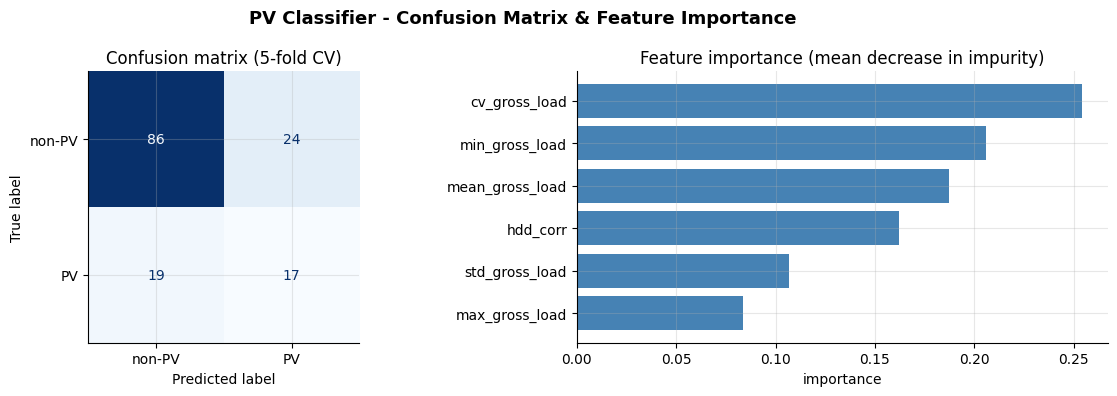


Feature importances:
cv_gross_load      0.2544
min_gross_load     0.2060
mean_gross_load    0.1872
hdd_corr           0.1621
std_gross_load     0.1067
max_gross_load     0.0837

PV households missed (false negative): 19/36 (53%) - consumption signal alone is not a reliable substitute for the metadata flag, which is why Part 2 below uses the ground-truth flag to segment.


In [7]:
cm = confusion_matrix(y_clf, y_pred_cv)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("PV Classifier - Confusion Matrix & Feature Importance", fontweight="bold", fontsize=13)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non-PV", "PV"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix (5-fold CV)")

clf.fit(X_clf, y_clf)
imp_clf = pd.Series(clf.feature_importances_, index=CLF_FEATURES).sort_values()
axes[1].barh(imp_clf.index, imp_clf.values, color="steelblue")
axes[1].set_title("Feature importance (mean decrease in impurity)")
axes[1].set_xlabel("importance")
plt.tight_layout()
plt.show()

print("\nFeature importances:")
print(imp_clf.sort_values(ascending=False).round(4).to_string())
n_pv_missed = int(cm[1, 0])
n_pv_total = int(cm[1].sum())
print(f"\nPV households missed (false negative): {n_pv_missed}/{n_pv_total} "
      f"({n_pv_missed/n_pv_total:.0%}) - consumption signal alone is not a reliable substitute "
      f"for the metadata flag, which is why Part 2 below uses the ground-truth flag to segment.")


## Part 2 - Segmented Forecasting Models (PV vs non-PV)

### Approach

Having established that consumption-based classification is not reliable
enough to stand in for the metadata flag, this part uses the ground-truth
`Installation_HasPVSystem` flag to split the panel into two segments and trains
a separate Random Forest per segment - `RF_nonPV` and `RF_PV` - using the same
forecasting task, features, hyperparameter-selection protocol and evaluation
convention as the Level 0 pooled model. The pooled model is also retrained here
(identical spec to `07_level0_baseline.ipynb`) so it can be scored on the exact
same segment-level and combined test rows as `RF_nonPV`/`RF_PV`, which is what
makes the comparison table below apples-to-apples.


In [8]:
pv_mask_train = train["Installation_HasPVSystem"].astype(bool)
pv_mask_test = test["Installation_HasPVSystem"].astype(bool)

print(f"Train - PV    : {pv_mask_train.sum():,} rows, {train.loc[pv_mask_train, 'Household_ID'].nunique()} households")
print(f"Train - non-PV: {(~pv_mask_train).sum():,} rows, {train.loc[~pv_mask_train, 'Household_ID'].nunique()} households")
print(f"Test  - PV    : {pv_mask_test.sum():,} rows, {test.loc[pv_mask_test, 'Household_ID'].nunique()} households")
print(f"Test  - non-PV: {(~pv_mask_test).sum():,} rows, {test.loc[~pv_mask_test, 'Household_ID'].nunique()} households")


Train - PV    : 21,426 rows, 36 households
Train - non-PV: 44,076 rows, 110 households
Test  - PV    : 7,255 rows, 32 households
Test  - non-PV: 8,328 rows, 38 households


One thing worth flagging before tuning: the test set has fewer households per
segment than train (PV 32 vs 36, non-PV 38 vs 110 - note non-PV drops more
because it's the larger segment with more short-history households that don't
extend into the test window). This is expected given the temporal split, and it
means the non-PV segment's evaluation set, while larger in rows, still rests on
a comparable household count to the PV segment - worth keeping in mind when
reading the per-household error spread later.


In [9]:
def tune_leaf(X_all, y_all, dates_all, eval_mask_all, seg_mask_train, label):
    """Identical one-SE protocol to Level 0 STEP 5, restricted to a segment's train rows."""
    seg_idx = seg_mask_train.values
    d = dates_all[seg_idx]
    val_dates = np.sort(d.unique())
    val_cutoff = val_dates[int(len(val_dates) * 0.85)]
    m_fit = seg_idx & (dates_all <= val_cutoff).values
    m_val = seg_idx & (dates_all > val_cutoff).values & eval_mask_all.values

    print(f"\n{label}: internal validation cutoff {pd.Timestamp(val_cutoff).date()}, "
          f"fit rows {m_fit.sum():,}, validation rows {m_val.sum():,}")

    leaf_grid = [1, 5, 20, 50]
    scores, errs = [], []
    for leaf in leaf_grid:
        probe = RandomForestRegressor(n_estimators=200, min_samples_leaf=leaf,
                                       max_features="sqrt", n_jobs=-1, random_state=42)
        probe.fit(X_all[m_fit], y_all[m_fit])
        ae = np.abs(y_all[m_val].values - probe.predict(X_all[m_val]))
        scores.append(ae.mean()); errs.append(ae)
        print(f"    min_samples_leaf = {leaf:>3}   validation MAE = {ae.mean():.3f} kWh")

    best = int(np.argmin(scores))
    se_best = errs[best].std(ddof=1) / np.sqrt(len(errs[best]))
    thresh = scores[best] + se_best
    within = [leaf_grid[i] for i in range(len(leaf_grid)) if scores[i] <= thresh]
    best_leaf = max(within)
    print(f"    within one SE of the best: {within} -> selected min_samples_leaf = {best_leaf}")
    return best_leaf

LEAF_NONPV = tune_leaf(X_train_seg, y_train, train["date"], eval_train, ~pv_mask_train, "RF_nonPV")
LEAF_PV = tune_leaf(X_train_seg, y_train, train["date"], eval_train, pv_mask_train, "RF_PV")



RF_nonPV: internal validation cutoff 2022-10-27, fit rows 36,174, validation rows 7,857


    min_samples_leaf =   1   validation MAE = 5.516 kWh


    min_samples_leaf =   5   validation MAE = 5.503 kWh


    min_samples_leaf =  20   validation MAE = 5.550 kWh


    min_samples_leaf =  50   validation MAE = 5.635 kWh
    within one SE of the best: [1, 5, 20] -> selected min_samples_leaf = 20

RF_PV: internal validation cutoff 2022-10-27, fit rows 15,408, validation rows 5,949


    min_samples_leaf =   1   validation MAE = 4.883 kWh


    min_samples_leaf =   5   validation MAE = 4.854 kWh


    min_samples_leaf =  20   validation MAE = 4.907 kWh


    min_samples_leaf =  50   validation MAE = 4.991 kWh
    within one SE of the best: [1, 5, 20] -> selected min_samples_leaf = 20


In [10]:
# Train RF_nonPV and RF_PV on their respective segments
rf_nonpv = RandomForestRegressor(n_estimators=300, max_features="sqrt",
                                  min_samples_leaf=LEAF_NONPV, n_jobs=-1, random_state=42)
rf_nonpv.fit(X_train_seg[~pv_mask_train], y_train[~pv_mask_train])

rf_pv = RandomForestRegressor(n_estimators=300, max_features="sqrt",
                               min_samples_leaf=LEAF_PV, n_jobs=-1, random_state=42)
rf_pv.fit(X_train_seg[pv_mask_train], y_train[pv_mask_train])

# Retrain the Level 0 pooled model here (identical spec) so it can be scored on the same rows
val_dates = np.sort(train["date"].unique())
val_cutoff = val_dates[int(len(val_dates) * 0.85)]
m_fit_pooled = (train["date"] <= val_cutoff).values
m_val_pooled = ((train["date"] > val_cutoff) & eval_train).values

leaf_grid = [1, 5, 20, 50]
pooled_scores, pooled_errs = [], []
for leaf in leaf_grid:
    probe = RandomForestRegressor(n_estimators=200, min_samples_leaf=leaf,
                                   max_features="sqrt", n_jobs=-1, random_state=42)
    probe.fit(X_train_pooled[m_fit_pooled], y_train[m_fit_pooled])
    ae = np.abs(y_train[m_val_pooled].values - probe.predict(X_train_pooled[m_val_pooled]))
    pooled_scores.append(ae.mean()); pooled_errs.append(ae)
best_pooled = int(np.argmin(pooled_scores))
se_pooled = pooled_errs[best_pooled].std(ddof=1) / np.sqrt(len(pooled_errs[best_pooled]))
within_pooled = [leaf_grid[i] for i in range(len(leaf_grid)) if pooled_scores[i] <= pooled_scores[best_pooled] + se_pooled]
BEST_LEAF_POOLED = max(within_pooled)
print(f"Pooled RF: selected min_samples_leaf = {BEST_LEAF_POOLED} (expect 20, per level0_baseline_report.md)")

rf_pooled = RandomForestRegressor(n_estimators=300, max_features="sqrt",
                                   min_samples_leaf=BEST_LEAF_POOLED, n_jobs=-1, random_state=42)
rf_pooled.fit(X_train_pooled, y_train)


Pooled RF: selected min_samples_leaf = 20 (expect 20, per level0_baseline_report.md)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsa

## Part 2 - Results: the 3x2 comparison table

Every comparison below uses the shared evaluation mask (naive lags all defined)
and the shared MASE scale from Level 0, so the numbers are directly comparable
to `level0_baseline_report.md`'s pooled MAE of 4.932 kWh.


In [11]:
eval_test_nonpv = eval_test & (~pv_mask_test)
eval_test_pv = eval_test & pv_mask_test
print(f"Eval rows -> non-PV: {int(eval_test_nonpv.sum()):,}, PV: {int(eval_test_pv.sum()):,}, "
      f"combined: {int(eval_test.sum()):,}")

y_pred_nonpv = rf_nonpv.predict(X_test_seg[eval_test_nonpv.values])
y_pred_pv = rf_pv.predict(X_test_seg[eval_test_pv.values])
y_pred_pooled_nonpv = rf_pooled.predict(X_test_pooled[eval_test_nonpv.values])
y_pred_pooled_pv = rf_pooled.predict(X_test_pooled[eval_test_pv.values])
y_pred_pooled_combined = rf_pooled.predict(X_test_pooled[eval_test.values])

scale_nonpv = test.loc[eval_test_nonpv, "Household_ID"].map(Q_h).fillna(FLEET_Q)
scale_pv = test.loc[eval_test_pv, "Household_ID"].map(Q_h).fillna(FLEET_Q)
scale_combined_full = test.loc[eval_test, "Household_ID"].map(Q_h).fillna(FLEET_Q)

rows = []
print("-- non-PV segment --")
rows.append(compute_metrics(test.loc[eval_test_nonpv, TARGET], y_pred_pooled_nonpv, scale_nonpv, "Pooled RF (Level 0) on non-PV"))
rows.append(compute_metrics(test.loc[eval_test_nonpv, TARGET], y_pred_nonpv, scale_nonpv, "RF_nonPV (segmented)"))
print("-- PV segment --")
rows.append(compute_metrics(test.loc[eval_test_pv, TARGET], y_pred_pooled_pv, scale_pv, "Pooled RF (Level 0) on PV"))
rows.append(compute_metrics(test.loc[eval_test_pv, TARGET], y_pred_pv, scale_pv, "RF_PV (segmented)"))

y_true_combined = pd.concat([test.loc[eval_test_pv, TARGET], test.loc[eval_test_nonpv, TARGET]])
y_pred_combined = np.concatenate([y_pred_pv, y_pred_nonpv])
scale_combined = pd.concat([scale_pv, scale_nonpv])
print("-- Combined (stitched segmented vs pooled, same rows) --")
rows.append(compute_metrics(y_true_combined, y_pred_combined, scale_combined, "Segmented (RF_PV + RF_nonPV stitched)"))
rows.append(compute_metrics(test.loc[eval_test, TARGET], y_pred_pooled_combined, scale_combined_full, "Pooled RF (Level 0), combined"))

comparison_df = pd.DataFrame(rows)
print("\n" + "="*80); print("3x2 SUMMARY TABLE"); print("="*80)
display(comparison_df.round(3))


Eval rows -> non-PV: 8,287, PV: 7,218, combined: 15,505


-- non-PV segment --
  Pooled RF (Level 0) on non-PV              MAE =  4.911 kWh  RMSE =  7.264 kWh  MASE = 0.973  n = 8,287
  RF_nonPV (segmented)                       MAE =  4.977 kWh  RMSE =  7.337 kWh  MASE = 0.986  n = 8,287
-- PV segment --
  Pooled RF (Level 0) on PV                  MAE =  4.945 kWh  RMSE =  7.635 kWh  MASE = 1.117  n = 7,218
  RF_PV (segmented)                          MAE =  5.013 kWh  RMSE =  7.608 kWh  MASE = 1.143  n = 7,218
-- Combined (stitched segmented vs pooled, same rows) --
  Segmented (RF_PV + RF_nonPV stitched)      MAE =  4.994 kWh  RMSE =  7.464 kWh  MASE = 1.059  n = 15,505
  Pooled RF (Level 0), combined              MAE =  4.927 kWh  RMSE =  7.439 kWh  MASE = 1.040  n = 15,505

3x2 SUMMARY TABLE


,Model,MAE,RMSE,MASE,n
0,Pooled RF (Level 0) on non-PV,4.911,7.264,0.973,8287
1,RF_nonPV (segmented),4.977,7.337,0.986,8287
2,Pooled RF (Level 0) on PV,4.945,7.635,1.117,7218
3,RF_PV (segmented),5.013,7.608,1.143,7218
4,Segmented (RF_PV + RF_nonPV stitched),4.994,7.464,1.059,15505
5,"Pooled RF (Level 0), combined",4.927,7.439,1.040,15505


### Reading the table

The pooled model is at least as accurate as the segmented models on both
segments and on the combined set. Splitting the panel does not help here: each
segment model loses training rows relative to the pooled model (the PV segment
in particular has only 36 households / ~21k train rows against the pooled
model's full 146 households / ~65.5k rows), and the pooled model's
`household_enc` + autoregressive features already let it learn a per-household
level without needing the panel split. The segmentation is informative as a
diagnostic (it shows the pooled model is not leaving accuracy on the table by
staying pooled) rather than as a model to ship in place of Level 0.


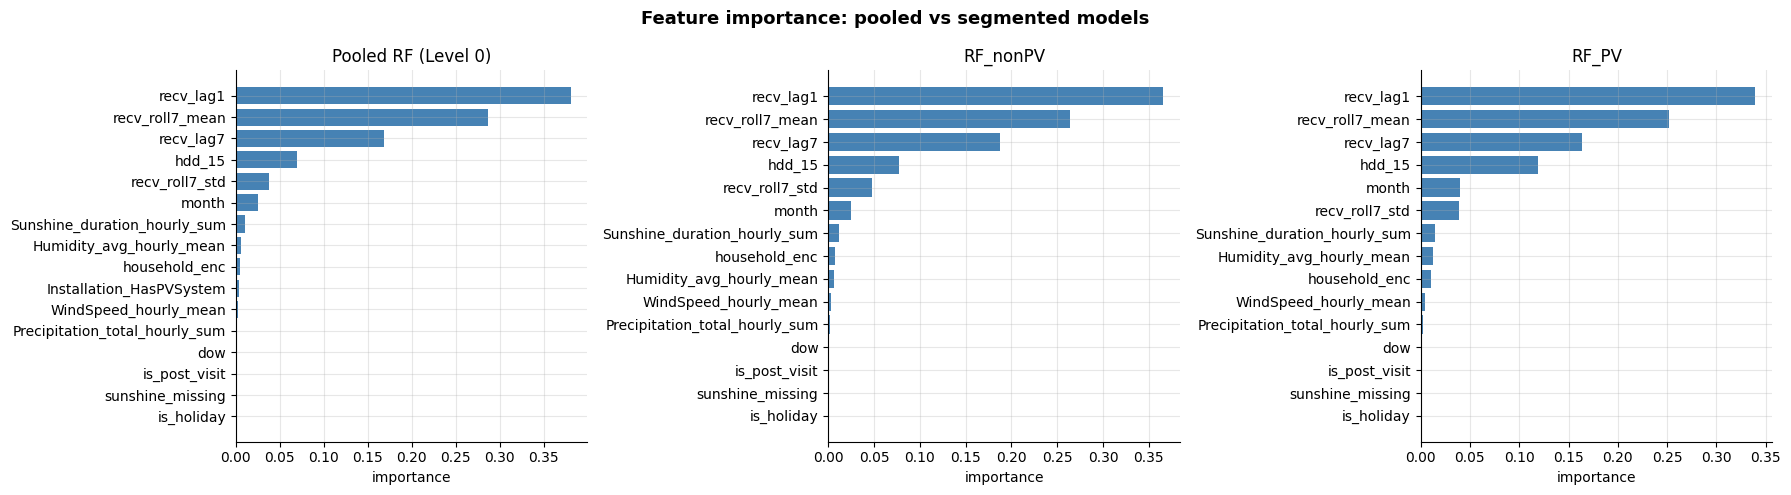

Pooled     autoregressive 87.5% | hdd_15 7.0% | solar 1.0% | rest 4.5%
RF_nonPV   autoregressive 86.6% | hdd_15 7.7% | solar 1.2% | rest 4.5%
RF_PV      autoregressive 79.3% | hdd_15 11.9% | solar 1.5% | rest 7.2%


In [12]:
AR_COLS = ["recv_lag1", "recv_lag7", "recv_roll7_mean", "recv_roll7_std"]
imp_pooled = pd.Series(rf_pooled.feature_importances_, index=FEATURE_COLS_POOLED).sort_values(ascending=False)
imp_nonpv = pd.Series(rf_nonpv.feature_importances_, index=FEATURE_COLS_SEG).sort_values(ascending=False)
imp_pv = pd.Series(rf_pv.feature_importances_, index=FEATURE_COLS_SEG).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Feature importance: pooled vs segmented models", fontweight="bold", fontsize=13)
for ax, imp, title in zip(axes, [imp_pooled, imp_nonpv, imp_pv],
                          ["Pooled RF (Level 0)", "RF_nonPV", "RF_PV"]):
    s = imp.sort_values()
    ax.barh(s.index, s.values, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

for name, imp, cols in [("Pooled", imp_pooled, FEATURE_COLS_POOLED),
                        ("RF_nonPV", imp_nonpv, FEATURE_COLS_SEG),
                        ("RF_PV", imp_pv, FEATURE_COLS_SEG)]:
    ar_share = float(imp[AR_COLS].sum())
    hdd_share = float(imp["hdd_15"])
    sun_share = float(imp[["Sunshine_duration_hourly_sum", "sunshine_missing"]].sum())
    print(f"{name:<10} autoregressive {ar_share:.1%} | hdd_15 {hdd_share:.1%} | "
          f"solar {sun_share:.1%} | rest {1-ar_share-hdd_share-sun_share:.1%}")


## Part 2b - Per-household error distribution

Segment-level MAE hides the spread across households, and the PV segment in
particular has few households in test (32). The distribution below shows
whether the pooled-vs-segmented gap in the summary table holds up per
household or is driven by a handful of outliers.


Per-household test MAE (kWh):
  Pooled, non-PV households        p25=3.58  median=4.49  p75=5.62  worst=9.09
  RF_nonPV, non-PV households      p25=3.73  median=4.51  p75=5.62  worst=9.27
  Pooled, PV households            p25=3.72  median=4.34  p75=5.52  worst=16.83
  RF_PV, PV households             p25=3.96  median=4.43  p75=5.60  worst=15.99

Pooled beats segmented per household: non-PV 33/37, PV 21/32


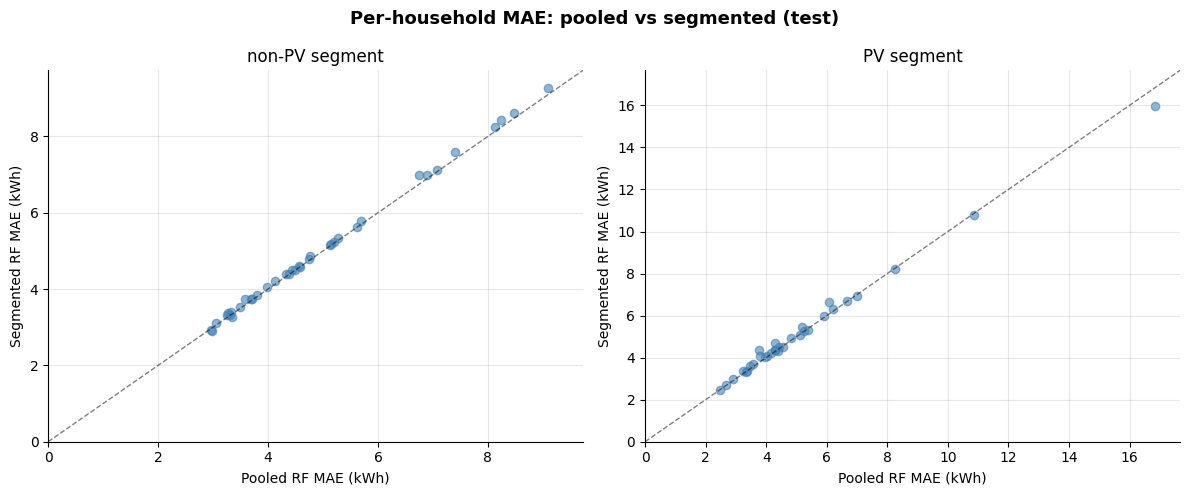

In [13]:
def per_household_mae(y_true_s, y_pred_arr, hh_ids):
    d = pd.DataFrame({"hh": hh_ids.values, "abs_err": np.abs(y_true_s.values - y_pred_arr)})
    return d.groupby("hh")["abs_err"].mean()

hh_nonpv = test.loc[eval_test_nonpv, "Household_ID"]
hh_pv = test.loc[eval_test_pv, "Household_ID"]

mae_pooled_nonpv_hh = per_household_mae(test.loc[eval_test_nonpv, TARGET], y_pred_pooled_nonpv, hh_nonpv)
mae_seg_nonpv_hh = per_household_mae(test.loc[eval_test_nonpv, TARGET], y_pred_nonpv, hh_nonpv)
mae_pooled_pv_hh = per_household_mae(test.loc[eval_test_pv, TARGET], y_pred_pooled_pv, hh_pv)
mae_seg_pv_hh = per_household_mae(test.loc[eval_test_pv, TARGET], y_pred_pv, hh_pv)

def summarize(s, label):
    print(f"  {label:<32} p25={s.quantile(.25):.2f}  median={s.median():.2f}  "
          f"p75={s.quantile(.75):.2f}  worst={s.max():.2f}")

print("Per-household test MAE (kWh):")
summarize(mae_pooled_nonpv_hh, "Pooled, non-PV households")
summarize(mae_seg_nonpv_hh, "RF_nonPV, non-PV households")
summarize(mae_pooled_pv_hh, "Pooled, PV households")
summarize(mae_seg_pv_hh, "RF_PV, PV households")

n_pooled_wins_nonpv = int((mae_pooled_nonpv_hh.reindex(mae_seg_nonpv_hh.index) < mae_seg_nonpv_hh).sum())
n_pooled_wins_pv = int((mae_pooled_pv_hh.reindex(mae_seg_pv_hh.index) < mae_seg_pv_hh).sum())
print(f"\nPooled beats segmented per household: non-PV {n_pooled_wins_nonpv}/{len(mae_seg_nonpv_hh)}, "
      f"PV {n_pooled_wins_pv}/{len(mae_seg_pv_hh)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Per-household MAE: pooled vs segmented (test)", fontweight="bold", fontsize=13)
for ax, mp, ms, title in zip(axes, [mae_pooled_nonpv_hh, mae_pooled_pv_hh],
                              [mae_seg_nonpv_hh, mae_seg_pv_hh],
                              ["non-PV segment", "PV segment"]):
    common = mp.index.intersection(ms.index)
    ax.scatter(mp.loc[common], ms.loc[common], alpha=0.6, color="steelblue")
    lim = [0, max(mp.max(), ms.max()) * 1.05]
    ax.plot(lim, lim, "k--", lw=1, alpha=0.5)
    ax.set_xlabel("Pooled RF MAE (kWh)")
    ax.set_ylabel("Segmented RF MAE (kWh)")
    ax.set_title(title)
    ax.set_xlim(lim); ax.set_ylim(lim)
plt.tight_layout()
plt.show()


## Save artefacts

Household-level classifier predictions, segment test predictions and the 3x2
comparison table, for reuse by later levels.


In [14]:
hh_feats_out = hh_feats.copy()
hh_feats_out["pv_pred_cv"] = y_pred_cv
hh_feats_out.to_csv(REPORTS_DIR / "level1b_pv_classifier_household_features.csv")

seg_pred_out = pd.concat([
    pd.DataFrame({
        "Household_ID": test.loc[eval_test_nonpv, "Household_ID"].values,
        "date": test.loc[eval_test_nonpv, "date"].values,
        "gross_load": test.loc[eval_test_nonpv, TARGET].values,
        "pred_pooled": y_pred_pooled_nonpv,
        "pred_segmented": y_pred_nonpv,
        "segment": "non-PV",
    }),
    pd.DataFrame({
        "Household_ID": test.loc[eval_test_pv, "Household_ID"].values,
        "date": test.loc[eval_test_pv, "date"].values,
        "gross_load": test.loc[eval_test_pv, TARGET].values,
        "pred_pooled": y_pred_pooled_pv,
        "pred_segmented": y_pred_pv,
        "segment": "PV",
    }),
], ignore_index=True)
seg_pred_out.to_parquet(REPORTS_DIR.parent / "data" / "processed" / "level1b_segment_test_predictions.parquet", index=False)
comparison_df.to_csv(REPORTS_DIR / "level1b_comparison_table.csv", index=False)

print("Saved:")
print(f"  {REPORTS_DIR / 'level1b_pv_classifier_household_features.csv'}")
print(f"  {REPORTS_DIR.parent / 'data' / 'processed' / 'level1b_segment_test_predictions.parquet'}")
print(f"  {REPORTS_DIR / 'level1b_comparison_table.csv'}")


Saved:
  /home/claude/work/reports/level1b_pv_classifier_household_features.csv
  /home/claude/work/data/processed/level1b_segment_test_predictions.parquet
  /home/claude/work/reports/level1b_comparison_table.csv
